# DSN AI Bootcamp Qualification Hackathon 2026
## Machine Learning Track — Product Sales Prediction

### Objective
Build a machine learning model that predicts `total_sales` for a product sold at a particular store.

In [80]:
import pandas as pd

# Load the datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (6818, 13)
Test shape: (1705, 12)
Sample submission shape: (1705, 2)


In [81]:
print("TRAIN DATA")
display(train.head())

TRAIN DATA


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [82]:
print("TEST DATA")
display(test.head())

TEST DATA


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [83]:
print("SAMPLE SUBMISSION")
display(sample_submission.head())

SAMPLE SUBMISSION


,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


Understanding the Structure of the dataset

In [84]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 692.6 KB


In [85]:
print("Training data summary:")
display(train.describe())

Training data summary:


,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [86]:
print("Missing values in training data:")
display(train.isnull().sum())

print("\nMissing values in test data:")
display(test.isnull().sum())

Missing values in training data:


id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64


Missing values in test data:


id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

In [87]:
print("Missing value percentages in training data:")
display((train.isnull().mean() * 100).sort_values(ascending=False))

Missing value percentages in training data:


store_size             28.146084
product_weight_kg      17.967146
id                      0.000000
fat_content             0.000000
product_code            0.000000
shelf_visibility        0.000000
product_category        0.000000
store_code              0.000000
product_price           0.000000
store_age_years         0.000000
store_location_tier     0.000000
store_format            0.000000
total_sales             0.000000
dtype: float64

### Observation

The main missing values are in `product_weight_kg` and `store_size`.

Instead of deleting these rows, the values will be handled later inside the preprocessing pipeline.
This prevents information from the validation data from influencing the preprocessing step.

In [88]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [89]:
numerical_cols = [
    "product_weight_kg",
    "shelf_visibility",
    "product_price",
    "store_age_years"
]

categorical_cols = [
    "fat_content",
    "product_category",
    "store_size",
    "store_location_tier",
    "store_format"
]

In [90]:
for col in categorical_cols:
    print(f"\n {col} ")
    print(train[col].value_counts(dropna=False))


 fat_content 
fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64

 product_category 
product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
soft dri

### Observation

Categorical values contain inconsistent formatting.

For example, values such as `Frozen Foods` and `frozen foods` may represent the same category.

If they are left unchanged, the model can treat them as two separate categories.

In [91]:
for col in categorical_cols:
    train[col] = train[col].astype("object")
    test[col] = test[col].astype("object")
    
    train[col] = train[col].apply(
        lambda x: x.strip().lower() if isinstance(x, str) else x
    )
    
    test[col] = test[col].apply(
        lambda x: x.strip().lower() if isinstance(x, str) else x
    )

### Cleaning performed

For the categorical columns, we:

- removed unnecessary spaces using `strip()`
- converted text to lowercase using `lower()`

This makes categories with different capitalization or accidental spaces consistent.

In [92]:
for col in categorical_cols:
    print(f"\n {col} after cleaning ")
    print(train[col].value_counts(dropna=False))


 fat_content after cleaning 
fat_content
low fat    4425
regular    2393
Name: count, dtype: int64

 product_category after cleaning 
product_category
fruits and vegetables    1006
snack foods               933
household                 740
frozen foods              675
dairy                     554
canned                    517
baking goods              516
health and hygiene        412
soft drinks               366
meat                      339
breads                    209
hard drinks               169
others                    132
starchy foods             113
breakfast                  85
seafood                    52
Name: count, dtype: int64

 store_size after cleaning 
store_size
medium    2218
small     1933
NaN       1919
large      748
Name: count, dtype: int64

 store_location_tier after cleaning 
store_location_tier
tier_3    2677
tier_2    2232
tier_1    1909
Name: count, dtype: int64

 store_format after cleaning 
store_format
standard supermarket    4462
corner shop   

In [93]:
display(train[numerical_cols].describe())

,product_weight_kg,shelf_visibility,product_price,store_age_years
count,5593.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205
std,4.646542,0.051566,62.413513,8.384574
min,4.482000,0.000000,31.110000,23.000000
25%,8.750000,0.026600,93.280000,28.000000
50%,12.647000,0.053200,142.065000,33.000000
75%,16.894000,0.093400,185.987500,45.000000
max,21.883000,0.320100,273.040000,47.000000


In [94]:
for col in numerical_cols:
    print(f"\n {col} ")
    print("Minimum:", train[col].min())
    print("Maximum:", train[col].max())
    print("Missing values:", train[col].isna().sum())


 product_weight_kg 
Minimum: 4.482
Maximum: 21.883
Missing values: 1225

 shelf_visibility 
Minimum: 0.0
Maximum: 0.3201
Missing values: 0

 product_price 
Minimum: 31.11
Maximum: 273.04
Missing values: 0

 store_age_years 
Minimum: 23
Maximum: 47
Missing values: 0


Now investigating the numerical ranges before making any decision about unusual values.

We will not automatically remove outliers because an extreme value may represent a genuine observation.

In [95]:
print("Total sales summary:")
display(train["total_sales"].describe())

Total sales summary:


count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [96]:
print("Lowest sales values:")
print(train["total_sales"].nsmallest(10))

print("\nHighest sales values:")
print(train["total_sales"].nlargest(10))

Lowest sales values:
1822    32.70
5253    33.30
1999    34.32
5550    34.56
502     34.79
3813    35.40
6046    36.15
1957    37.00
2144    37.43
3847    37.76
Name: total_sales, dtype: float64

Highest sales values:
5404    12996.82
4220    12359.04
235     10477.97
900     10130.90
5950     9999.51
2053     9803.38
5522     9768.51
2825     9564.04
3673     9537.99
745      9523.15
Name: total_sales, dtype: float64


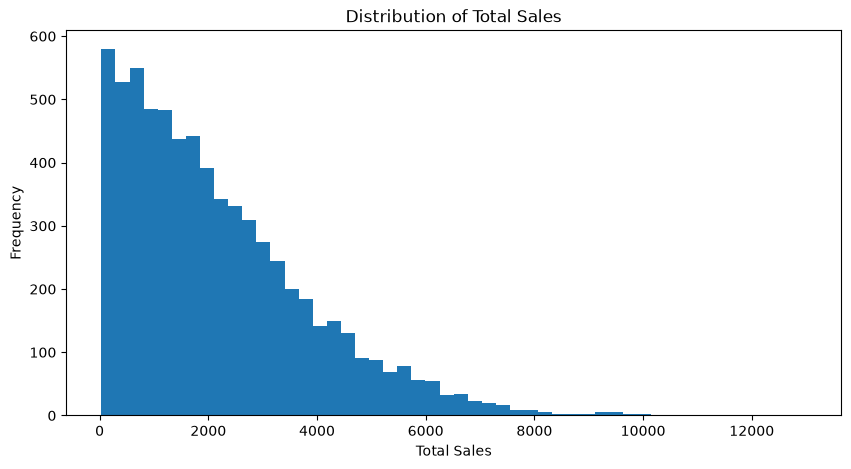

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train["total_sales"], bins=50)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales")
plt.show()

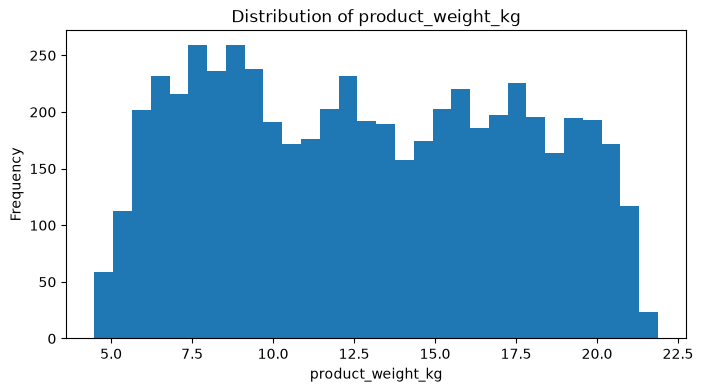

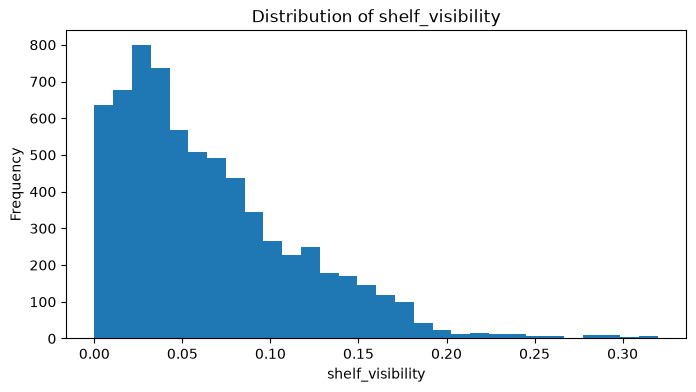

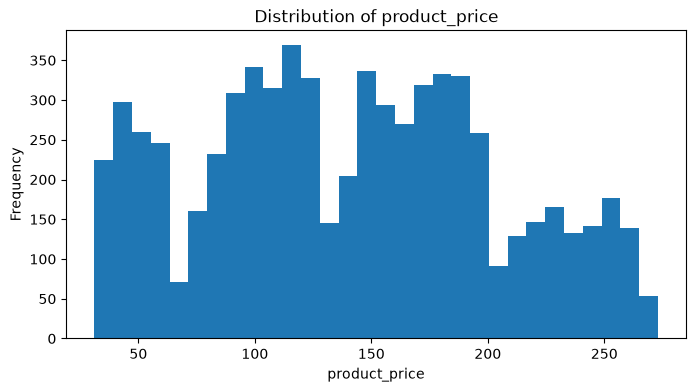

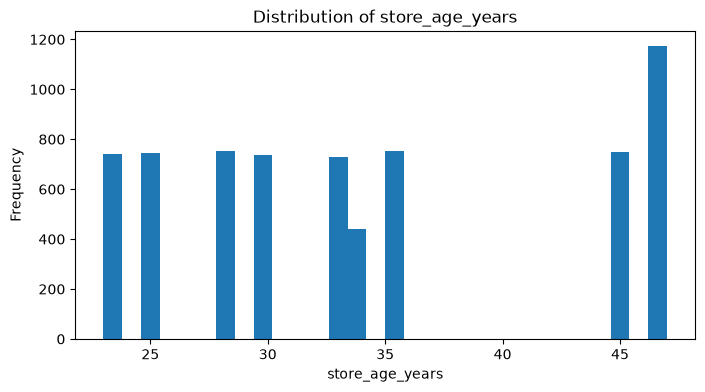

In [98]:
# Numerical features distributions

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(train[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

In [99]:
# Correlation Analysis

correlation = train[numerical_cols + ["total_sales"]].corr()

display(correlation)

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
product_weight_kg,1.000000,-0.013986,0.034824,0.009020,0.015532
shelf_visibility,-0.013986,1.000000,0.003905,0.071078,-0.118124
product_price,0.034824,0.003905,1.000000,-0.012747,0.569833
store_age_years,0.009020,0.071078,-0.012747,1.000000,0.039443
total_sales,0.015532,-0.118124,0.569833,0.039443,1.000000


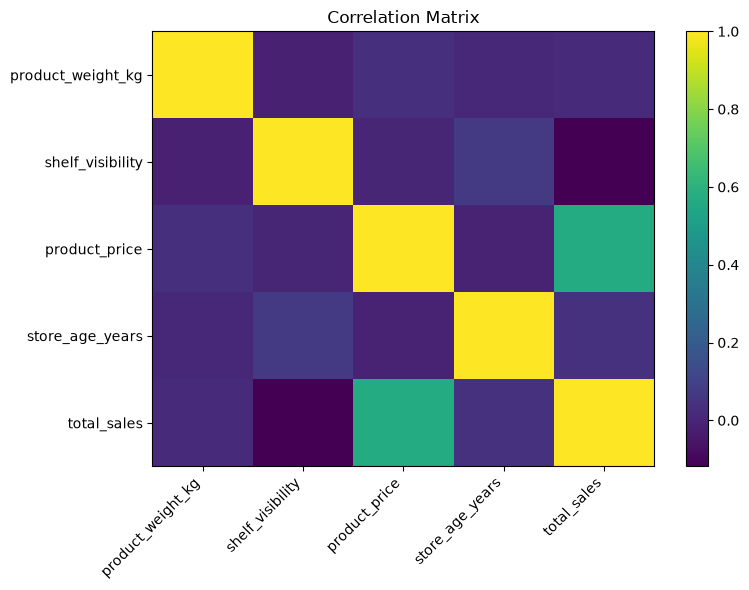

In [100]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [101]:
# Categorical Analysis

for col in categorical_cols:
    print(f"\n {col} ")
    print(train[col].value_counts(dropna=False))


 fat_content 
fat_content
low fat    4425
regular    2393
Name: count, dtype: int64

 product_category 
product_category
fruits and vegetables    1006
snack foods               933
household                 740
frozen foods              675
dairy                     554
canned                    517
baking goods              516
health and hygiene        412
soft drinks               366
meat                      339
breads                    209
hard drinks               169
others                    132
starchy foods             113
breakfast                  85
seafood                    52
Name: count, dtype: int64

 store_size 
store_size
medium    2218
small     1933
NaN       1919
large      748
Name: count, dtype: int64

 store_location_tier 
store_location_tier
tier_3    2677
tier_2    2232
tier_1    1909
Name: count, dtype: int64

 store_format 
store_format
standard supermarket    4462
corner shop              866
flagship hypermarket     748
superstore               742
Na

In [102]:
# Sales by store format

store_format_sales = train.groupby("store_format")["total_sales"].agg(
    ["mean", "median", "count"]
).sort_values("mean", ascending=False)

display(store_format_sales)

,mean,median,count
store_format,,,
flagship hypermarket,3660.182219,3348.085,748
standard supermarket,2316.319677,1998.270,4462
superstore,1971.661954,1622.170,742
corner shop,336.353868,252.150,866


In [103]:
# Sales by Product Category

product_category_sales = train.groupby("product_category")["total_sales"].agg(
    ["mean", "median", "count"]
).sort_values("mean", ascending=False)

display(product_category_sales)

,mean,median,count
product_category,,,
starchy foods,2407.718584,2037.090,113
household,2292.464662,2023.745,740
fruits and vegetables,2277.854672,1816.565,1006
meat,2264.310383,1861.450,339
seafood,2262.524231,1929.040,52
dairy,2238.317076,1695.955,554
snack foods,2223.830568,1887.240,933
canned,2196.398743,1838.800,517
hard drinks,2189.723195,1842.880,169


In [104]:
# Product and Store Repition

print("Unique products:", train["product_code"].nunique())
print("Unique stores:", train["store_code"].nunique())
print("Unique IDs:", train["id"].nunique())

Unique products: 1555
Unique stores: 10
Unique IDs: 6818


In [105]:
product_store_combinations = train[
    ["product_code", "store_code"]
].drop_duplicates()

print(
    "Unique product-store combinations:",
    len(product_store_combinations)
)

Unique product-store combinations: 6818


## Model Preparation

The target variable is `total_sales`.

The `id`, `product_code`, and `store_code` columns will not be used as raw features in this model.

I tested the raw product/store codes earlier and obtained a slightly better validation RMSE when they were removed.


In [106]:
X = train.drop(columns=["total_sales"])
y = train["total_sales"]

# Remove identifier columns from the model
X = X.drop(columns=["id", "product_code", "store_code"])

## Model Development

Training data into an 80% training set and a 20% validation set.

The same validation split is used throughout the model experiments so that model comparisons are controlled and meaningful.

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

Training rows: 5454
Validation rows: 1364


## Baseline Model

Before using a machine learning model, I create a simple baseline.

The baseline predicts the average `total_sales` from the training data for every validation row.

This gives us a reference point for judging whether the machine learning model is actually learning useful patterns.

In [108]:
baseline_prediction = y_train.mean()

baseline_predictions = [baseline_prediction] * len(y_valid)

In [109]:
from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_valid,
    baseline_predictions
)

baseline_rmse = baseline_mse ** 0.5

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 1716.8662994066603


## Data Preprocessing

The dataset contains missing values and categorical variables.

- fill missing numerical values with the median
- fill missing categorical values with the most frequent category
- convert categorical variables into numerical features using one-hot encoding

The preprocessing is placed inside a pipeline so that it is fitted only on the training data.

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [111]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [112]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [113]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [114]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [115]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['product_weight_kg','fat_content','shelf_visibility',...,'store_size', 'store_location_tier','store_format']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pa

In [116]:
print(X_train.dtypes)

product_weight_kg      float64
fat_content                str
shelf_visibility       float64
product_category           str
product_price          float64
store_age_years          int64
store_size                 str
store_location_tier        str
store_format               str
dtype: object


In [117]:
y_pred = model_pipeline.predict(X_valid)

rf_mse = mean_squared_error(y_valid, y_pred)
rf_rmse = rf_mse ** 0.5

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 1115.5508991296715


In [118]:
# Compare Baseline and Random Forest

results = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Random Forest"
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ]
})

display(results)

,Model,RMSE
0,Mean Baseline,1716.866299
1,Random Forest,1115.550899


In [119]:
improvement = (
    (baseline_rmse - rf_rmse)
    / baseline_rmse
) * 100

print(f"Improvement over baseline: {improvement:.2f}%")

Improvement over baseline: 35.02%


##  CatBoost Model

In [120]:
import catboost
print(catboost.__version__)

1.2.10


In [121]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [122]:
# Removed the target and identifier columns
# keeping product_code and store_code out for this first experiment

X_catboost = train.drop(
    columns=["total_sales", "id", "product_code", "store_code"]
)

y_catboost = train["total_sales"]


# Split the data using the same random_state as previous models
X_catboost_train, X_catboost_valid, y_catboost_train, y_catboost_valid = train_test_split(
    X_catboost,
    y_catboost,
    test_size=0.2,
    random_state=42
)

In [123]:
# List of categorical columns
catboost_categorical_cols = [
    "fat_content",
    "product_category",
    "store_size",
    "store_location_tier",
    "store_format"
]


# Filled missing categorical values with a clear label
# This tells CatBoost that the value was missing

for col in catboost_categorical_cols:
    X_catboost_train[col] = X_catboost_train[col].fillna("missing")
    X_catboost_valid[col] = X_catboost_valid[col].fillna("missing")


# Convert categorical columns to strings
for col in catboost_categorical_cols:
    X_catboost_train[col] = X_catboost_train[col].astype(str)
    X_catboost_valid[col] = X_catboost_valid[col].astype(str)

In [124]:
# Create the CatBoost regression model

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)


# Train the model
catboost_model.fit(
    X_catboost_train,
    y_catboost_train,
    cat_features=catboost_categorical_cols
)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [125]:
# Make predictions on the validation data
catboost_pred = catboost_model.predict(
    X_catboost_valid
)


# Calculate RMSE
catboost_mse = mean_squared_error(
    y_catboost_valid,
    catboost_pred
)

catboost_rmse = catboost_mse ** 0.5


print("CatBoost RMSE:", catboost_rmse)

CatBoost RMSE: 1076.7221522783082


##  Testing Product and Store Identity

The dataset contains `product_code` and `store_code`.

Because these are identifiers, I tested them separately rather than assuming that they improve the model.

The experiments used the same validation split and CatBoost settings.

Results:

- CatBoost: 1076.722
- CatBoost + store_code: 1078.00
- CatBoost + product_code: 1077.90

Neither identifier improved the validation RMSE.

Therefore, the final model excludes both raw identifiers.

## 9. CatBoost Hyperparameter Tuning

After establishing CatBoost as the strongest algorithm, I tested selected hyperparameters while keeping the validation split unchanged.

The experiments showed that reducing tree depth improved validation performance.

The best results obtained were:

- Depth 6, learning rate 0.05: RMSE 1076.722
- Depth 4, learning rate 0.05: RMSE 1070.63
- Depth 3, learning rate 0.05: RMSE 1067.79
- Depth 3, learning rate 0.03: RMSE 1067.52

The final configuration is therefore:

- iterations = 500
- learning_rate = 0.03
- depth = 3
- random_seed = 42

In [126]:
final_validation_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

In [127]:
final_validation_model.fit(
    X_catboost_train,
    y_catboost_train,
    cat_features=catboost_categorical_cols
)

final_validation_pred = final_validation_model.predict(
    X_catboost_valid
)

In [128]:
final_validation_mse = mean_squared_error(
    y_catboost_valid,
    final_validation_pred
)

final_validation_rmse = final_validation_mse ** 0.5

print("Final validation RMSE:", final_validation_rmse)

Final validation RMSE: 1067.5179276006506


In [129]:
X_final = train.drop(
    columns=["total_sales", "id", "product_code", "store_code"]
)

y_final = train["total_sales"]

X_test_final = test.drop(
    columns=["id", "product_code", "store_code"]
)

In [130]:
final_categorical_cols = [
    "fat_content",
    "product_category",
    "store_size",
    "store_location_tier",
    "store_format"
]

for col in final_categorical_cols:
    X_final[col] = X_final[col].fillna("missing")
    X_test_final[col] = X_test_final[col].fillna("missing")

    X_final[col] = X_final[col].astype(str)
    X_test_final[col] = X_test_final[col].astype(str)

In [131]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

final_model.fit(
    X_final,
    y_final,
    cat_features=final_categorical_cols
)

print("Final model trained successfully.")

Final model trained successfully.


The final model is now used to predict `total_sales` for every row in the competition test dataset.

In [132]:
test_predictions = final_model.predict(
    X_test_final
)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 1705
First 10 predictions:
[2775.68308033 4182.69470062 3143.96875215 3322.57187451 2462.63743368
  398.70411437 3896.02343671 3198.63691115  351.37569176 2060.62790132]


In [133]:
submission = pd.DataFrame({
    "id": test["id"],
    "total_sales": test_predictions
})

submission.head()

,id,total_sales
0,row_00009,2775.683080
1,row_00015,4182.694701
2,row_00019,3143.968752
3,row_00020,3322.571875
4,row_00023,2462.637434


In [134]:
print("Submission shape:", submission.shape)

print("\nColumns:")
print(submission.columns.tolist())

print("\nMissing predictions:")
print(submission["total_sales"].isna().sum())

Submission shape: (1705, 2)

Columns:
['id', 'total_sales']

Missing predictions:
0


## Final Submission

The submission file contains the required `id` and predicted `total_sales` columns.

In [135]:
submission.to_csv(
    "submission.csv",
    index=False
)

# Conclusion
### Key findings

The exploratory analysis showed that sales vary across product and store characteristics, particularly store-related characteristics such as store format and location tier.

Several regression models were evaluated using the same validation approach.

The best initial tree-based model was Gradient Boosting with a validation RMSE of approximately 1080.79.

CatBoost performed better and was therefore selected for further investigation.

Raw `product_code` and `store_code` were tested separately. Neither improved the CatBoost validation performance, so they were excluded from the final model.

CatBoost hyperparameter experiments showed that shallower trees improved the validation result.

The final configuration was:

- Algorithm: CatBoost Regressor
- Iterations: 500
- Learning rate: 0.03
- Depth: 3
- Random seed: 42

Final validation RMSE:

**1067.52**

After selecting the model, it was retrained using the complete training dataset and used to generate predictions for all rows in `test.csv`.

The final predictions were saved as:

`submission.csv`

## Further Experiments

After developing and comparing the baseline, Random Forest, and CatBoost models, additional experiments were conducted to investigate possible improvements.

Because the `total_sales` target showed a right-skewed distribution, a log transformation (`log1p`) of the target was tested using 5-fold cross-validation. The original target produced a mean RMSE of **1083.46**, while the log-transformed target produced **1089.47**. Therefore, the log transformation did not improve performance under this evaluation setup.

Target encoding was also explored for `store_code` and `product_code`, using historical average `total_sales` while avoiding target leakage during cross-validation. The combined target-encoding and log-transformation experiment produced a mean RMSE of approximately **1249.54**, which was higher than the original-target approach.

Based on these experiments, the original target representation was retained for the final model.